# External validation figures and Figure 2

Draw ideological-identification results from held-out predictions and assemble the main Figure 2.

**Inputs:** participant-level out-of-fold predictions, fold metrics, feature importances, and activity summaries in `outputs/validation`, generated by notebook 05. Spatial coordinates in `data/processed/figure_inputs/spatial` come from notebook 09. Figure 2 panels a–c in `outputs/panels` come from notebooks 11–12. All these inputs are included.

**Outputs:** Figures 2, S2, S4, S5, and S8 in `outputs/figures`, with supporting tables in `outputs/tables/validation`.

**Run or explore:** run top to bottom in a fresh kernel. You can use this notebook alone with the bundled inputs. After changing validation or spatial analyses, regenerate the corresponding inputs in their source notebooks before composing the figure.

The embedding fits are fixed inputs, so external cross-validation is transductive with respect to those unsupervised fits. Right is the positive class. Ideological labels were not used to estimate the maps. The figure is assembled on a blank vector page and displayed from that live page before export.


In [1]:
from pathlib import Path
from io import BytesIO
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, SVG
import fitz
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."

DATA = ROOT / "outputs/validation"
assert DATA.is_dir(), "Start in the package root or notebooks folder."
OUT = ROOT / "outputs/figures"
PANELS = ROOT / "outputs/panels"
TABLES = ROOT / "outputs/tables/validation"
for directory in (OUT, PANELS, TABLES):
    directory.mkdir(parents=True, exist_ok=True)
COUNTRIES = ["Chile", "France", "Brazil"]
COLORS = {"Chile": "#7B3294", "France": "#0072B2", "Brazil": "#E69F00"}
MARKERS = {"Chile": "o", "France": "s", "Brazil": "^"}
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


## Read predictions and check the comparisons

Out-of-fold (OOF) predictions assign each person the prediction from the fold that excluded them during classifier training. Within a country, all four classifiers must use the same participant IDs, targets, and folds so their scores can be compared directly.

The checks recompute fold accuracy, AUC, and confusion counts from those participant-level predictions. They also verify that classifier coordinates match the fitted map. France uses the same axis swap and reflection as the spatial figures. Boxplots show the ten actual fold accuracies. ROC curves pool OOF probabilities across folds.


In [2]:
summaries, folds, oof = {}, {}, {}
check_rows = []
for country in COUNTRIES:
    directory = DATA / country
    summaries[country] = json.loads((directory / "metrics_summary.json").read_text())
    reference = None
    for model in ["coordinates", "demographics", "combined", "pc1"]:
        folds[country, model] = pd.read_csv(
            (directory / f"{model}_fold_metrics.csv")
        ).sort_values("fold")
        predictions = (
            pd.read_csv(
                (directory / f"{model}_oof_predictions.csv"),
                dtype={"participant_id": str},
                float_precision="round_trip",
            )
            .sort_values("participant_id")
            .reset_index(drop=True)
        )
        oof[country, model] = predictions
        assert predictions.participant_id.is_unique
        assert set(predictions.target.unique()) == {0, 1}
        assert predictions.fold.nunique() >= 2
        assert set(folds[country, model].fold) == set(predictions.fold)
        identity = predictions[["participant_id", "target", "fold"]]
        if reference is None:
            reference = identity
        else:
            pd.testing.assert_frame_equal(reference, identity)
        # Check the fold scores that are plotted, as well as the pooled summaries.
        for fold, held_out in predictions.groupby("fold"):
            recorded = folds[country, model].set_index("fold").loc[fold]
            assert recorded.n_test == len(held_out)
            assert np.isclose(
                recorded.accuracy, accuracy_score(held_out.target, held_out.prediction)
            )
            assert np.isclose(
                recorded.auc, roc_auc_score(held_out.target, held_out.probability_right)
            )
        if model in ("combined", "demographics"):
            recorded_curve = pd.read_csv(directory / f"{model}_roc.csv")
            fpr, tpr, _ = roc_curve(predictions.target, predictions.probability_right)
            assert np.allclose(recorded_curve.FPR, fpr)
            assert np.allclose(recorded_curve.TPR, tpr)
        summary = summaries[country][model]
        counts = confusion_matrix(predictions.target, predictions.prediction, labels=[0, 1])
        assert np.array_equal(counts, summary["confusion_counts_left_right"])
        assert np.isclose(
            accuracy_score(predictions.target, predictions.prediction), summary["oof_accuracy"]
        )
        assert np.isclose(
            roc_auc_score(predictions.target, predictions.probability_right), summary["oof_auc"]
        )
        check_rows.append(
            {
                "country": country,
                "model": model,
                "unique_participants": len(predictions),
                "folds": predictions.fold.nunique(),
                "oof_accuracy": summary["oof_accuracy"],
                "oof_auc": summary["oof_auc"],
            }
        )


## Match validation coordinates to the displayed maps

The participant-ID join checks the exact coordinates supplied to the random forest (RF). An axis swap or reflection preserves geometry, but must also be applied consistently when feature-importance labels are drawn.


In [3]:
# Verify the map-to-RF coordinate correspondence directly by participant ID.
for country in COUNTRIES:
    raw = pd.read_csv(
        (ROOT / "data/processed/figure_inputs/spatial" / f"{country}_coordsU.csv")
    )
    raw = raw.rename(columns={"uuid": "participant_id", "user_id": "participant_id"})
    eligible = pd.read_csv((DATA / country / "eligible_participants.csv"))
    assert set(eligible.participant_id.astype(str)) == set(
        oof[country, "combined"].participant_id
    )
    linked = eligible.merge(
        raw[["participant_id", "z1", "z2"]],
        on="participant_id",
        validate="one_to_one",
        suffixes=("_rf", "_raw"),
    )
    assert len(linked) == len(eligible)
    if country == "France":
        assert linked.z1_raw.between(0, 1).all()
        assert np.allclose(linked.z1_rf, linked.z2_raw)
        assert np.allclose(linked.z2_rf, 1 - linked.z1_raw)
    else:
        assert np.allclose(linked.z1_rf, linked.z1_raw)
        assert np.allclose(linked.z2_rf, linked.z2_raw)
validation_checks = pd.DataFrame(check_rows)
display(validation_checks)
validation_checks.to_csv(TABLES / "validation_summary.csv", index=False)
validation_checks.to_latex(TABLES / "validation_summary.tex", index=False, float_format="%.4f")


,country,model,unique_participants,folds,oof_accuracy,oof_auc
0,Chile,coordinates,22024,10,0.803305,0.867072
1,Chile,demographics,22024,10,0.561161,0.567266
2,Chile,combined,22024,10,0.815519,0.879207
3,Chile,pc1,22024,10,0.743870,0.837743
4,France,coordinates,788,10,0.912437,0.941808
5,France,demographics,788,10,0.817259,0.542912
6,France,combined,788,10,0.911168,0.945798
7,France,pc1,788,10,0.879442,0.901953
8,Brazil,coordinates,495,10,0.872727,0.931767
9,Brazil,demographics,495,10,0.737374,0.528304


## Figure 2: classifier results and vector composition

Panel d shows the ten observed fold accuracies for the combined classifier. Panel e shows mean impurity-based feature importance over those folds. This descriptive importance depends on feature encoding. It is not a causal effect or an additive decomposition of predictive performance. Missing bars mark unavailable features.

Map labels use a display coordinate convention that can differ from classifier column order. `ordered_features` explicitly matches each bar to the displayed axis. The smaller validation panel is built as a live Matplotlib figure and held in an in-memory PDF buffer. It is then placed beside the included panels a–c on a newly created vector page. No previous composite Figure 2 is read.


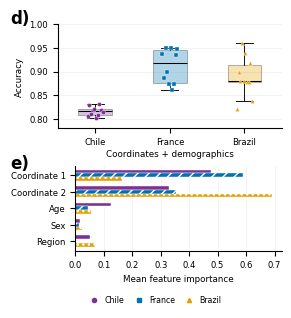

In [4]:
with plt.rc_context(
    {"font.size": 6.1, "axes.labelsize": 6.3, "xtick.labelsize": 6.1, "ytick.labelsize": 6.1}
):
    panel = plt.figure(figsize=(209.25 / 72, 226.25 / 72), facecolor="white")
    ax = panel.add_axes([0.19, 0.59, 0.77, 0.33])
    arrays = [folds[c, "combined"].accuracy.to_numpy() for c in COUNTRIES]
    boxes = ax.boxplot(
        arrays,
        positions=np.arange(3),
        widths=0.45,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 0.75},
        boxprops={"linewidth": 0.65},
        whiskerprops={"linewidth": 0.65},
        capprops={"linewidth": 0.65},
    )
    for i, country in enumerate(COUNTRIES):
        boxes["boxes"][i].set_facecolor(COLORS[country])
        boxes["boxes"][i].set_alpha(0.30)
        ax.scatter(
            i + np.linspace(-0.10, 0.10, len(arrays[i])),
            arrays[i],
            s=9,
            c=COLORS[country],
            marker=MARKERS[country],
            edgecolors="white",
            linewidths=0.25,
            zorder=3,
        )
    ax.set_xticks(np.arange(3), COUNTRIES)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Coordinates + demographics", labelpad=2)
    ax.set_ylim(
        max(0, np.floor(min(map(np.min, arrays)) * 20) / 20 - 0.02),
        min(1, np.ceil(max(map(np.max, arrays)) * 20) / 20 + 0.02),
    )
    ax.grid(axis="y", color="#eeeeee", linewidth=0.5)
    ax.set_axisbelow(True)
    panel.text(0.025, 0.967, "d)", fontsize=12, fontweight="bold", va="top")
    ax = panel.add_axes([0.25, 0.20, 0.71, 0.27])
    features = ["z1", "z2", "age", "sex", "region"]
    feature_names = ["Coordinate 1", "Coordinate 2", "Age", "Sex", "Region"]
    width = 0.23
    importance_rows = []
    for i, country in enumerate(COUNTRIES):
        # These inputs were fit on the corresponding training folds in notebook 05.
        frame = pd.read_csv((DATA / country / "combined_feature_importance_by_fold.csv"))
        # Match each named map dimension, not the spelling of the RF input column.
        ordered_features = (
            ["z1", "z2", "age", "sex", "region"]
            if country == "France"
            else ["z2", "z1", "age", "sex", "region"]
        )
        values = [frame[f].mean() if f in frame.columns else np.nan for f in ordered_features]
        for label, f, value in zip(feature_names, ordered_features, values):
            importance_rows.append(
                {
                    "country": country,
                    "display_feature": label,
                    "rf_input_feature": f,
                    "mean_importance": value,
                    "available": np.isfinite(value),
                }
            )
        ax.barh(
            np.arange(len(features)) + (i - 1) * width,
            values,
            height=width,
            color=COLORS[country],
            edgecolor="white",
            linewidth=0.3,
            hatch=["", "///", "..."][i],
        )
    ax.set_yticks(np.arange(len(features)), feature_names)
    ax.invert_yaxis()
    ax.set_xlabel("Mean feature importance")
    ax.set_xlim(left=0)
    ax.grid(axis="x", color="#eeeeee", linewidth=0.5)
    ax.set_axisbelow(True)
    panel.text(0.025, 0.505, "e)", fontsize=12, fontweight="bold", va="top")
    handles = [
        Line2D(
            [0],
            [0],
            marker=MARKERS[c],
            color=COLORS[c],
            linestyle="none",
            label=c,
            markersize=3,
        )
        for c in COUNTRIES
    ]
    panel.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.52, 0.005),
        ncol=3,
        frameon=False,
        fontsize=5.7,
        handletextpad=0.3,
        columnspacing=0.8,
    )
    display(panel)
    panel_buffer = BytesIO()
    panel.savefig(panel_buffer, format="pdf")
    plt.close(panel)


### Assemble the live vector page

The three included source panels are inputs. This cell creates a new page, places them alongside the validation panel generated above, displays the live SVG, and saves that same page as PDF.


In [5]:
# Each panel is a generated vector document. Panel a is the supplied editorial SVG.
# Starting from a blank page avoids importing any historical composite figure.
for name in ("Fig2a.pdf", "Fig2b.pdf", "Fig2c.pdf"):
    assert (
        PANELS / name
    ).is_file(), f"Missing bundled panel {name}. Regenerate it with notebooks 11 and 12."
composite = fitz.open()
page = composite.new_page(width=437.25, height=458.25)
a_source = fitz.open(PANELS / "Fig2a.pdf")
b_source = fitz.open(PANELS / "Fig2b.pdf")
c_source = fitz.open(PANELS / "Fig2c.pdf")
panel_pdf = fitz.open(stream=panel_buffer.getvalue(), filetype="pdf")
page.show_pdf_page(fitz.Rect(0, 16, 226, 226), a_source, 0, keep_proportion=True)
page.show_pdf_page(fitz.Rect(228, 0, 437.25, 226.25), b_source, 0, keep_proportion=True)
page.show_pdf_page(fitz.Rect(0, 232, 228, 458.25), c_source, 0, keep_proportion=True)
page.show_pdf_page(fitz.Rect(228, 232, 437.25, 458.25), panel_pdf, 0, keep_proportion=False)
page.insert_text((3, 12), "a)", fontsize=12, fontname="hebo")
page.insert_text((231, 12), "b)", fontsize=12, fontname="hebo")
# Display the live composite page before saving it, without reloading an export.
svg_from_live_page = page.get_svg_image
display(SVG(data=svg_from_live_page()))
composite.save(OUT / "Fig2.pdf", garbage=4, deflate=True)
importance_table = pd.DataFrame(importance_rows)
display(importance_table)
importance_table.to_csv(TABLES / "Fig2_feature_importance.csv", index=False)
importance_table.to_latex(
    TABLES / "Fig2_feature_importance.tex", index=False, float_format="%.4f"
)
for document in (composite, a_source, b_source, c_source, panel_pdf):
    document.close()


,country,display_feature,rf_input_feature,mean_importance,available
0,Chile,Coordinate 1,z2,0.476823,True
1,Chile,Coordinate 2,z1,0.329379,True
2,Chile,Age,age,0.126316,True
3,Chile,Sex,sex,0.014736,True
4,Chile,Region,region,0.052746,True
5,France,Coordinate 1,z1,0.590632,True
6,France,Coordinate 2,z2,0.353201,True
7,France,Age,age,0.042768,True
8,France,Sex,sex,0.013399,True
9,France,Region,region,NaN,False


## S4: pooled out-of-fold ROC curves

Solid curves use coordinates plus demographics; dashed curves use demographics alone. AUCs are read from the verified OOF summaries. Country panel labels are structural labels, not separate figure titles.

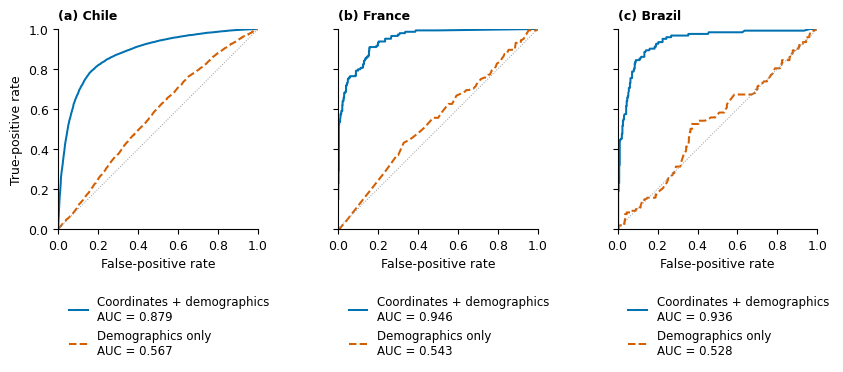

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(8.7, 3.7), sharex=True, sharey=True)
for index, (ax, country) in enumerate(zip(axes, COUNTRIES)):
    for model, style, color, label in [
        ("combined", "-", "#0072B2", "Coordinates + demographics"),
        ("demographics", "--", "#D55E00", "Demographics only"),
    ]:
        curve = pd.read_csv((DATA / country / f"{model}_roc.csv"))
        auc = summaries[country][model]["oof_auc"]
        ax.plot(
            curve.FPR,
            curve.TPR,
            linestyle=style,
            color=color,
            lw=1.45,
            label=f"{label}\nAUC = {auc:.3f}",
        )
    ax.plot([0, 1], [0, 1], color=".6", ls=":", lw=0.7)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="False-positive rate")
    ax.set_aspect("equal")
    ax.text(0, 1.05, f"({chr(97+index)}) {country}", transform=ax.transAxes, fontweight="bold")
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0, -0.28),
        frameon=False,
        fontsize=8.5,
        handlelength=1.6,
    )
axes[0].set_ylabel("True-positive rate")
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.36, top=0.90, wspace=0.16)
display(fig)
path = OUT / "FigS4.pdf"
fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.04)
plt.close(fig)


## S5: combined-classifier out-of-fold confusion matrices

Rows are self-reported classes; columns are predicted classes. Percentages normalize within each true class and counts are the exact OOF counts, so unequal class totals remain visible.

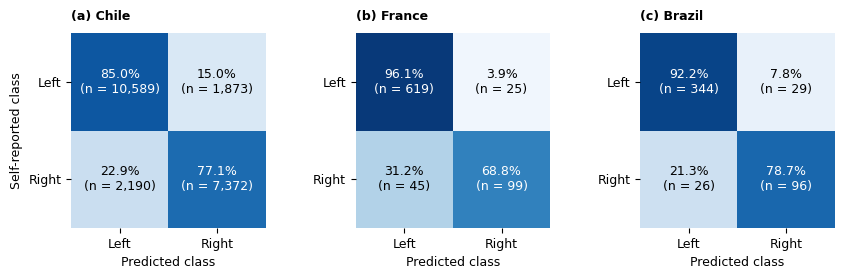

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(8.7, 2.9))
for index, (ax, country) in enumerate(zip(axes, COUNTRIES)):
    counts = np.asarray(summaries[country]["combined"]["confusion_counts_left_right"])
    normalized = counts / counts.sum(axis=1, keepdims=True)
    ax.pcolormesh(
        np.arange(3) - 0.5, np.arange(3) - 0.5, normalized, vmin=0, vmax=1, cmap="Blues"
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    for row in range(2):
        for column in range(2):
            ax.text(
                column,
                row,
                f"{normalized[row,column]:.1%}\n(n = {counts[row,column]:,})",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if normalized[row, column] > 0.60 else "black",
            )
    ax.set_xticks([0, 1], ["Left", "Right"])
    ax.set_yticks([0, 1], ["Left", "Right"])
    ax.set_xlabel("Predicted class")
    ax.text(0, 1.07, f"({chr(97+index)}) {country}", transform=ax.transAxes, fontweight="bold")
    for spine in ax.spines.values():
        spine.set_visible(False)
axes[0].set_ylabel("Self-reported class")
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.18, top=0.85, wspace=0.23)
display(fig)
path = OUT / "FigS5.pdf"
fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.04)
plt.close(fig)


## S8: matched-fold coordinate versus PC1 accuracy

Each thin line joins the two scores from one identical validation fold. Every point is an observed fold accuracy. The thick black segment joins the ten-fold means. PC1 is computed by notebook 05 from the same fixed coordinate fit.

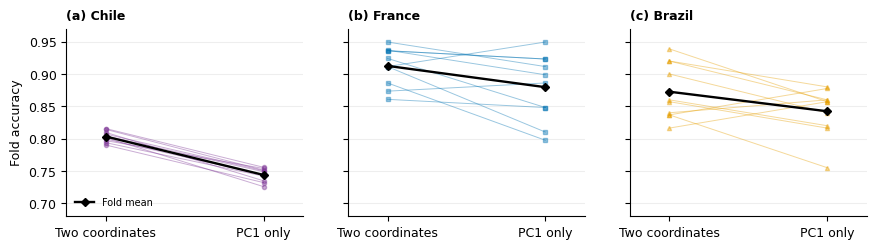

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(8.7, 2.8), sharey=True)
all_values = []
for index, (ax, country) in enumerate(zip(axes, COUNTRIES)):
    a = folds[country, "coordinates"][["fold", "accuracy"]]
    b = folds[country, "pc1"][["fold", "accuracy"]]
    paired = a.merge(b, on="fold", validate="one_to_one", suffixes=("_coordinates", "_pc1"))
    values = paired[["accuracy_coordinates", "accuracy_pc1"]].to_numpy()
    all_values.extend(values.ravel())
    for pair in values:
        ax.plot(
            [0, 1],
            pair,
            color=COLORS[country],
            alpha=0.40,
            lw=0.7,
            marker=MARKERS[country],
            markersize=3,
        )
    ax.plot(
        [0, 1],
        values.mean(axis=0),
        color="black",
        lw=1.7,
        marker="D",
        markersize=4,
        label="Fold mean",
    )
    ax.set_xticks([0, 1], ["Two coordinates", "PC1 only"])
    ax.set_xlim(-0.25, 1.25)
    ax.text(0, 1.05, f"({chr(97+index)}) {country}", transform=ax.transAxes, fontweight="bold")
    ax.grid(axis="y", color="#eeeeee")
    ax.set_axisbelow(True)
    if index == 0:
        ax.legend(frameon=False, fontsize=7, loc="lower left")
axes[0].set_ylabel("Fold accuracy")
axes[0].set_ylim(
    max(0, np.floor(min(all_values) * 20) / 20 - 0.02),
    min(1, np.ceil(max(all_values) * 20) / 20 + 0.02),
)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.18, top=0.85, wspace=0.19)
display(fig)
path = OUT / "FigS8.pdf"
fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.04)
plt.close(fig)


## S2: observed activity groups and OOF accuracy

The input table groups unique participants by observed comparison-record counts within country using quantile bins, with tied counts kept together. Points are the combined classifier's pooled OOF accuracy among participants in each observed group. There is no interpolation and no claim that their histories were experimentally truncated. Each discrete horizontal position is an observed count-range group; the annotations give the exact group size and error count.

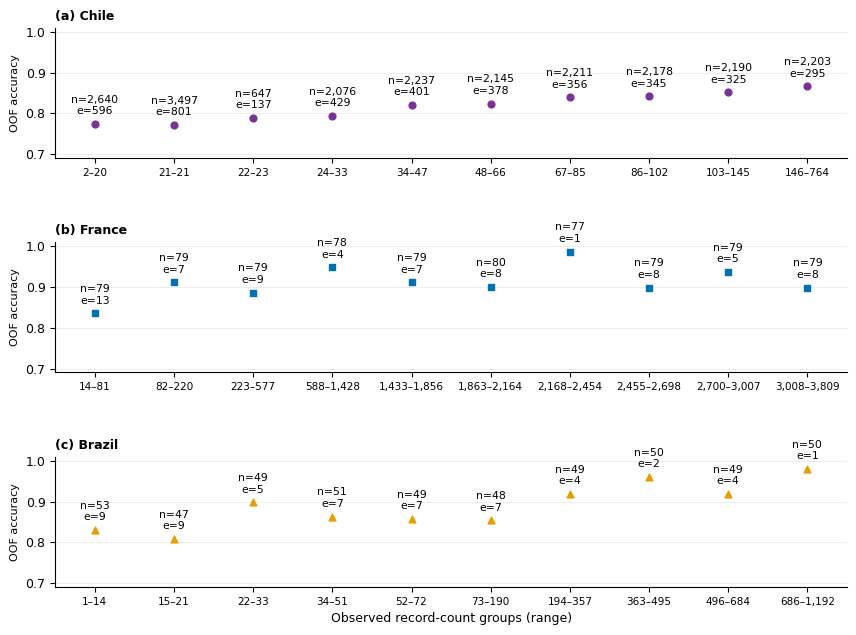

,country,group,n,n_left,n_right,count_min,count_median,count_max,accuracy,recall_left,recall_right,error_count
0,Chile,1,2640,1258,1382,2,19.0,20,0.774242,0.795707,0.754703,596
1,Chile,2,3497,2161,1336,21,21.0,21,0.770947,0.826932,0.680389,801
2,Chile,3,647,385,262,22,22.0,23,0.788253,0.844156,0.706107,137
3,Chile,4,2076,1243,833,24,28.0,33,0.793353,0.839903,0.723890,429
4,Chile,5,2237,1378,859,34,40.0,47,0.820742,0.859942,0.757858,401
5,Chile,6,2145,1216,929,48,56.0,66,0.823776,0.851151,0.787944,378
6,Chile,7,2211,1242,969,67,79.0,85,0.838987,0.855072,0.818369,356
7,Chile,8,2178,1188,990,86,95.0,102,0.841598,0.881313,0.793939,345
8,Chile,9,2190,1220,970,103,118.0,145,0.851598,0.879508,0.816495,325
9,Chile,10,2203,1171,1032,146,200.0,764,0.866092,0.879590,0.850775,295


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8.7, 6.5), sharey=True)
activity_frames = []
for index, (ax, country) in enumerate(zip(axes, COUNTRIES)):
    activity = pd.read_csv((DATA / country / "activity_groups.csv")).sort_values("count_median")
    assert activity.n.sum() == len(oof[country, "combined"])
    assert np.allclose(activity.accuracy, 1 - activity.error_count / activity.n)
    activity_frames.append(activity)
    ax.scatter(
        np.arange(len(activity)),
        activity.accuracy,
        color=COLORS[country],
        marker=MARKERS[country],
        s=24,
        zorder=3,
    )
    for i, row in enumerate(activity.itertuples()):
        ax.annotate(
            f"n={row.n:,}\ne={row.error_count:,}",
            (i, row.accuracy),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=7.8,
        )
    ax.set_xticks(
        np.arange(len(activity)),
        [f"{int(a):,}–{int(b):,}" for a, b in zip(activity.count_min, activity.count_max)],
        fontsize=7.5,
    )
    ax.set_xlim(-0.5, len(activity) - 0.5)
    ax.set_ylabel("OOF accuracy", fontsize=8)
    ax.text(0, 1.06, f"({chr(97+index)}) {country}", transform=ax.transAxes, fontweight="bold")
    ax.grid(axis="y", color="#eeeeee")
    ax.set_axisbelow(True)
activity_plot_data = pd.concat(activity_frames, ignore_index=True)
values = activity_plot_data.accuracy
axes[0].set_ylim(max(0, values.min() - 0.08), min(1.01, values.max() + 0.07))
axes[-1].set_xlabel("Observed record-count groups (range)", fontsize=9)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.08, top=0.94, hspace=0.65)
display(fig)
path = OUT / "FigS2.pdf"
fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.04)
plt.close(fig)
display(activity_plot_data)
activity_plot_data.to_csv(TABLES / "FigS2_activity_groups.csv", index=False)
activity_plot_data.to_latex(
    TABLES / "FigS2_activity_groups.tex", index=False, float_format="%.4f"
)
